# Lab 1

## Estimating worst-case/average-case complexity of algorithms via linear and binary search.

### 1. Linear Search

In [1]:
import math
import random

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd

In [2]:
n = 0 # no. of iterations

In [3]:
def linearSearch(arr, q):
    global n
    for i in range(1, len(arr)):
        n = n + 1
        if (arr[i] == q):
            return i

In [4]:
def testLinearSearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    # Run the algorithm
    linearSearch(arr,q)
    return n, (arr, q)                                      # Modifications as mentioned by Faculty

def data_builder(n):
    arr = []
    for i in range(1, n):
        # print(10**i)
        for j in range(1, 10):
            arr.append((10**i)*j)
    return arr

def run_n_times(iterations, sample_size):
    # initialise datastores
    test_sizes = data_builder(sample_size)
    results = [0 for i in range(len(test_sizes))]
    arr_queries_datastore = []                              # Modifications as mentioned by Faculty
    # run the tests for iterations
    for i in range(iterations):
        for j in range(len(test_sizes)):
            n, (arr, queries) = testLinearSearch(test_sizes[j], test_sizes[j])
            results[j] += n
            arr_queries_datastore.append((arr, queries, n)) # Modifications as mentioned by Faculty
    # calculate avg comparisons
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return (test_sizes, results, arr_queries_datastore)     # Modifications as mentioned by Faculty

In [5]:
ITER_RUNS = 25
RUN_SIZE = 4
test_sizes, results, arr_queries_datastore = run_n_times(ITER_RUNS, RUN_SIZE)

In [6]:
for i in range(len(arr_queries_datastore)):
    row = arr_queries_datastore[i]
    row_modifiable = list(row)
    row_modifiable.append(len(row_modifiable[0]))
    row = tuple(row_modifiable)
    arr_queries_datastore[i] = row

In [7]:
results_dataset = pd.DataFrame(arr_queries_datastore, columns=['Array', 'Query', 'Iterations', 'Data Size']) # Modifications as mentioned by Faculty

In [8]:
results_dataset

,Array,Query,Iterations,Data Size
0,"[5, 8, 3, 8, 6, 7, 5, 2, 0, 6]",6,4,10
1,"[1, 18, 1, 1, 3, 18, 3, 11, 16, 20, 3, 19, 11,...",14,19,20
2,"[22, 2, 3, 12, 19, 10, 19, 1, 18, 12, 17, 20, ...",27,12,30
3,"[26, 33, 39, 18, 25, 23, 28, 40, 8, 5, 17, 32,...",23,5,40
4,"[25, 22, 2, 30, 43, 8, 10, 6, 42, 16, 42, 45, ...",23,27,50
...,...,...,...,...
670,"[1818, 3879, 2366, 327, 4758, 755, 2503, 1762,...",1636,4999,5000
671,"[1471, 833, 2737, 3991, 5832, 1388, 5270, 2616...",881,1157,6000
672,"[3548, 3, 5239, 6666, 6667, 3991, 6448, 3118, ...",6683,2211,7000
673,"[4874, 4929, 7450, 3974, 2287, 4139, 4434, 123...",6583,1117,8000


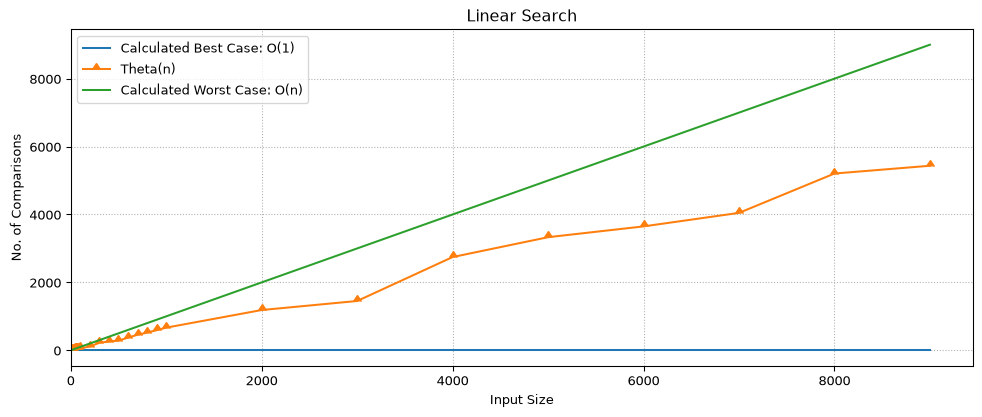

In [9]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # best case
y2 = results[:] # avg case
y3 = [i for i in test_sizes[:]] # worst case

plt.plot(x, y1, label="Calculated Best Case: O(1)")
plt.plot(x, y2, label="Theta(n)", marker=10)
plt.plot(x, y3, label="Calculated Worst Case: O(n)")

plt.xlim(left=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 2. Binary Search

In [10]:
n=0
def binarySearch(arr, q, low, high):
    global n
    if (low > high) or ((low == high) and (q != low)) or (high >= len(arr)):
        return None
    mid = int((high - low)//2) + low
    if arr[mid] == q:
        n += 1
        return mid
    if q < arr[mid]:
        n += 1
        return binarySearch(arr, q, low, mid-1)
    if q > arr[mid]:
        n += 1
        return binarySearch(arr, q, mid+1, high)
    return None

In [11]:
def testBinarySearch(num, maxRandLimit):
    # Build Data
    arr = []
    global n
    n = 0
    for i in range(num):
        arr.append(random.randint(0,maxRandLimit))
    q=random.randint(0,maxRandLimit)
    arr.sort()
    # Run the algorithm
    binarySearch(arr,q,0,num-1)
    return n, (arr, q)                                # Modifications as mentioned by Faculty

def run_n_times_binary(iterations, sample_size):
    # initialise datastores
    test_sizes = data_builder(sample_size)
    results = [0 for i in range(len(test_sizes))]
    arr_queries_datastore_b = []                              # Modifications as mentioned by Faculty
    # run the tests for iterations
    for i in range(iterations):
        for j in range(len(test_sizes)):
            n, (arr, queries) = testBinarySearch(test_sizes[j], test_sizes[j])
            results[j] += n
            arr_queries_datastore_b.append((arr, queries, n)) # Modifications as mentioned by Faculty
    # calculate avg comparisons
    for i in range(len(results)):
        results[i] = results[i]//iterations
    return (test_sizes, results, arr_queries_datastore_b)     # Modifications as mentioned by Faculty

In [12]:
ITER_RUNS = 25
RUN_SIZE = 4
test_sizes, results_b, arr_queries_datastore_b = run_n_times_binary(ITER_RUNS, RUN_SIZE)

In [13]:
for i in range(len(arr_queries_datastore_b)):
    row = arr_queries_datastore_b[i]
    row_modifiable = list(row)
    row_modifiable.append(len(row_modifiable[0]))
    row = tuple(row_modifiable)
    arr_queries_datastore_b[i] = row

In [14]:
results_dataset_b = pd.DataFrame(arr_queries_datastore_b, columns=['Array', 'Query', 'Iterations', 'Data Size']) # Modifications as mentioned by Faculty

In [15]:
results_dataset_b

,Array,Query,Iterations,Data Size
0,"[1, 1, 2, 4, 5, 6, 6, 7, 9, 10]",2,3,10
1,"[0, 2, 2, 2, 3, 7, 8, 10, 12, 12, 13, 15, 15, ...",0,4,20
2,"[1, 3, 5, 5, 7, 7, 8, 11, 11, 13, 15, 15, 15, ...",2,4,30
3,"[2, 4, 5, 5, 7, 7, 8, 11, 11, 12, 12, 12, 13, ...",6,5,40
4,"[0, 1, 1, 1, 2, 2, 2, 5, 9, 9, 12, 15, 15, 16,...",39,6,50
...,...,...,...,...
670,"[0, 1, 3, 3, 4, 5, 6, 8, 8, 8, 8, 8, 10, 10, 1...",2482,11,5000
671,"[2, 2, 2, 4, 4, 4, 5, 7, 7, 9, 10, 10, 12, 14,...",3715,12,6000
672,"[0, 0, 2, 2, 3, 3, 5, 5, 7, 7, 8, 10, 11, 12, ...",5825,6,7000
673,"[0, 0, 1, 1, 1, 3, 5, 6, 7, 8, 9, 10, 10, 12, ...",5742,12,8000


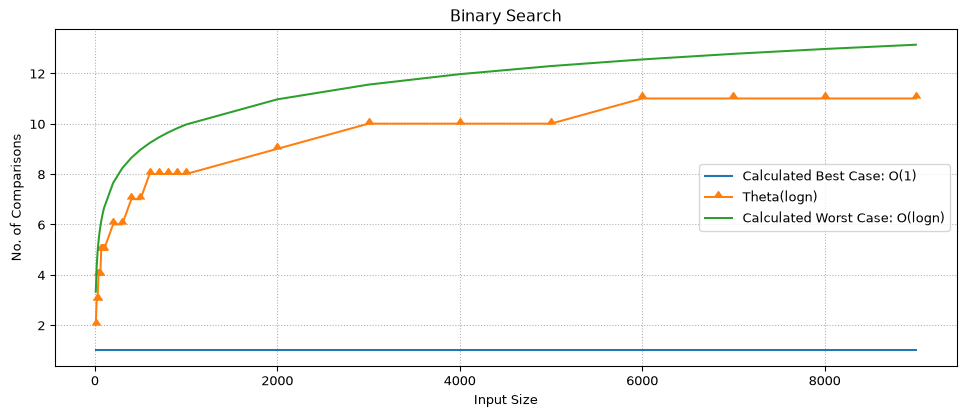

In [16]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # best case
y2 = results_b[:] # avg case
y3 = [math.log2(i) for i in test_sizes[:]] # worst case

plt.plot(x, y1, label="Calculated Best Case: O(1)")
plt.plot(x, y2, label="Theta(logn)", marker=10)
plt.plot(x, y3, label="Calculated Worst Case: O(logn)")

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 3. Comparison b/w Linear and Binary Search Algorithms

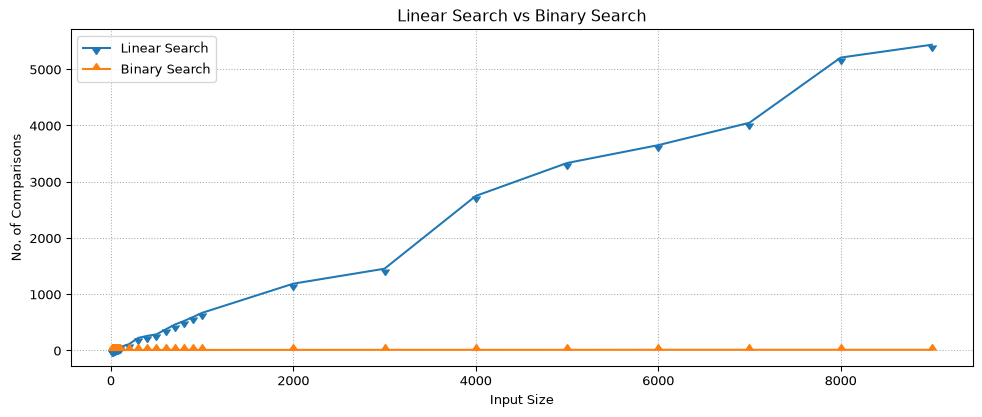

In [17]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = results[:] # Linear Search
y2 = results_b[:] # Binary Search

plt.plot(x, y1, label="Linear Search", marker=11)
plt.plot(x, y2, label="Binary Search", marker=10)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search vs Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

# Save the Datasets and Search Results

In [18]:
results_dataset.to_csv('2650026_lab1_data0.csv', index=False)
results_dataset_b.to_csv('2650026_lab1_data1.csv', index=False)